# Ćwiczenie 5 — Spline interpolacyjny: liniowy i kubiczny naturalny

## Część 1 — Spline liniowy

Dla zadanych węzłów interpolacyjnych konstruujemy spline liniowy, czyli funkcję sklejaną (określoną kawałkami), która w każdym przedziale $[x_{i-1}, x_i]$ jest wielomianem stopnia pierwszego:

$$S_i(x) = a_i(x - x_{i-1}) + b_i\qquad x_{i-1} \le x \le x_i$$

gdzie:

$$a_i = \frac{y_i - y_{i-1}}{x_i - x_{i-1}} = \frac{y_i - y_{i-1}}{h_i}, \quad b_i = y_{i-1}$$

**Zadanie:** Dla danych węzłów $(1, 2.7)$, $(2, 4.1)$, $(3, 8.2)$, $(4, 21.7)$ wyznacz spline liniowy i narysuj jego wykres.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([2.7, 4.1, 8.2, 21.7])

n = len(x)

In [3]:
def linear_spline(x_nodes, y_nodes, x_eval):
    """Ewaluacja spline'u liniowego w punktach x_eval.
    
    Parameters
    ----------
    x_nodes : array-like — węzły $x$
    y_nodes : array-like — wartości $y$
    x_eval  : array-like — punkty ewaluacji
    """
    x_eval = np.asarray(x_eval, dtype=float)
    result = np.empty_like(x_eval)
    for k, xv in enumerate(x_eval):
        if xv <= x_nodes[0]:
            idx = 0
        elif xv >= x_nodes[-1]:
            idx = len(x_nodes) - 2
        else:
            idx = np.searchsorted(x_nodes, xv) - 1

        h = x_nodes[idx + 1] - x_nodes[idx]
        a = (y_nodes[idx + 1] - y_nodes[idx]) / h
        b = y_nodes[idx]
        result[k] = a * (xv - x_nodes[idx]) + b
    return result

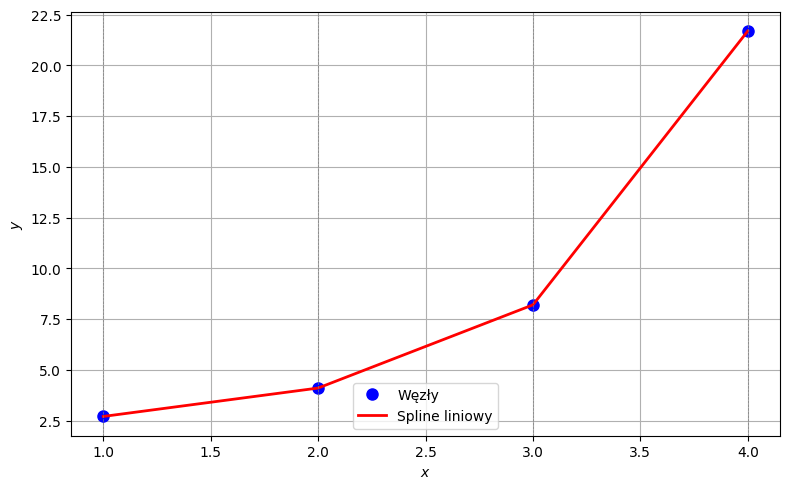

In [4]:
fine_x = np.linspace(x[0], x[-1], 401)
lin_y = linear_spline(x, y, fine_x)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, "bo", markersize=8, label="Węzły")
ax.plot(fine_x, lin_y, "r-", linewidth=2, label="Spline liniowy")
for xi in x:
    ax.axvline(xi, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Definicja 1: Spline kubiczny

Spline kubiczny to funkcja ciągła $S(x)$ spełniająca:
1. Na każdym przedziale $[x_{i-1}, x_i]$ jest to wielomian stopnia $\le 3$
2. $S(x_i) = y_i$ dla wszystkich węzłów
3. $S\in C^2[a,b]$ — ciągłość funkcji, pierwszej i drugiej pochodnej

Dla każdego przedziału $[x_{i-1}, x_i]$ spline kubiczny ma postać:

$$S_i(x) = M_{i-1}\frac{(x_i - x)^3}{6h_i} + M_i\frac{(x - x_{i-1})^3}{6h_i} + \left(y_{i-1} - \frac{M_{i-1}h_i^2}{6}\right)\frac{x_i - x}{h_i} + \left(y_i - \frac{M_i h_i^2}{6}\right)\frac{x - x_{i-1}}{h_i}$$

gdzie $h_i = x_i - x_{i-1}$ i $M_i = S''(x_i)$ — szukane drugie pochodne w węzłach.

## Część 2 — Spline kubiczny naturalny

Aby wyznaczyć $M_i$, korzystamy z warunku ciągłości pierwszej pochodnej: $S_i^{(1)}(x_i) = S_{i+1}^{(1)}(x_i)$, co prowadzi do układu:

$$\mu_i M_{i-1} + 2M_i + \lambda_i M_{i+1} = d_i$$

gdzie:
$$\mu_i = \frac{h_i}{h_i + h_{i+1}}, \quad\lambda_i = 1 - \mu_i = \frac{h_{i+1}}{h_i + h_{i+1}}, \quad d_i = 6f[x_{i-1}, x_i, x_{i+1}]$$

Dla spline naturalnego warunek brzegowy to:

$$M_0 = 0, \quad M_n = 0$$

Macierz układu ma postać:

$$\begin{bmatrix}
2 & 0 & 0 & \cdots & 0 \\
\mu_1 & 2 & \lambda_1 & \cdots & 0 \\
0 & \mu_2 & 2 & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & \lambda_{n-1} \\
0 & \cdots & 0 & 0 & 2
\end{bmatrix}
\begin{bmatrix} M_0 \\ M_1 \\ M_2 \\ \vdots \\ M_n \end{bmatrix}
=
\begin{bmatrix} 0 \\ d_1 \\ d_2 \\ \vdots \\ 0 \end{bmatrix}$$

Ponieważ w naszym przykładzie węzły są równomiernie rozmieszczone ($h_i = 1$),
mamy $\mu_i = \lambda_i = 0.5$.

In [5]:
h = np.diff(x)  # odległości między węzłami

# Macierz układu — tridiagonalna
A = 2.0 * np.eye(n)
A += 0.5 * np.eye(n, k=1)
A += 0.5 * np.eye(n, k=-1)
# Naturalne warunek brzegowy — zerujemy niegłówkowe elementy
A[0, 1] = 0.0
A[-1, -2] = 0.0

In [6]:
def divdiff_second(x_nodes, y_nodes):
    """Oblicza ilorazy różnicowe drugiego rzędu $f[x_{i-1},x_i,x_{i+1}]$."""
    n = len(x_nodes)
    dd = np.zeros((n, n))
    dd[:, 0] = y_nodes
    for j in range(1, n):
        for i in range(n - j):
            dd[i, j] = (dd[i+1, j-1] - dd[i, j-1]) / (x_nodes[i+j] - x_nodes[i])
    return dd

TDD = divdiff_second(x, y)
# Wektor prawej strony: [0, 6*d1, 6*d2, 0]
b = np.zeros(n)
b[1:-1] = 6.0 * TDD[:n-2, 2]

In [7]:
M = np.linalg.solve(A, b)
print("Drugie pochodne w węzłach (M):")
for i, mi in enumerate(M):
    print(f"  M_{i} = {mi:.6f}")

Drugie pochodne w węzłach (M):
  M_0 = 0.000000
  M_1 = 0.560000
  M_2 = 13.960000
  M_3 = 0.000000


In [8]:
from sympy import symbols, diff, collect

xxx = symbols("xxx")

def spline_segment(Mm1, Mi, ym1, yi, xm1, xi, h, var):
    """Symboliczne wyrażenie segmentu spline'u kubicznego."""
    S = (Mm1 * (xi - var)**3 / (6 * h)
         + Mi * (var - xm1)**3 / (6 * h)
         + (ym1 - Mm1 * h**2 / 6) * (xi - var) / h
         + (yi - Mi * h**2 / 6) * (var - xm1) / h)
    return collect(S, var)

S1 = spline_segment(M[0], M[1], y[0], y[1], x[0], x[1], h[0], xxx)
S2 = spline_segment(M[1], M[2], y[1], y[2], x[1], x[2], h[1], xxx)
S3 = spline_segment(M[2], M[3], y[2], y[3], x[2], x[3], h[2], xxx)

print("S1 =", S1)
print("S2 =", S2)
print("S3 =", S3)

S1 = 1.30666666666667*xxx + 0.0933333333333333*(xxx - 1.0)**3 + 1.39333333333333
S2 = 1.86666666666667*xxx + 2.52*(1 - 0.333333333333333*xxx)**3 + 18.6133333333333*(0.5*xxx - 1)**3 + 0.273333333333333
S3 = 15.8266666666667*xxx + 148.906666666667*(1 - 0.25*xxx)**3 - 41.6066666666667


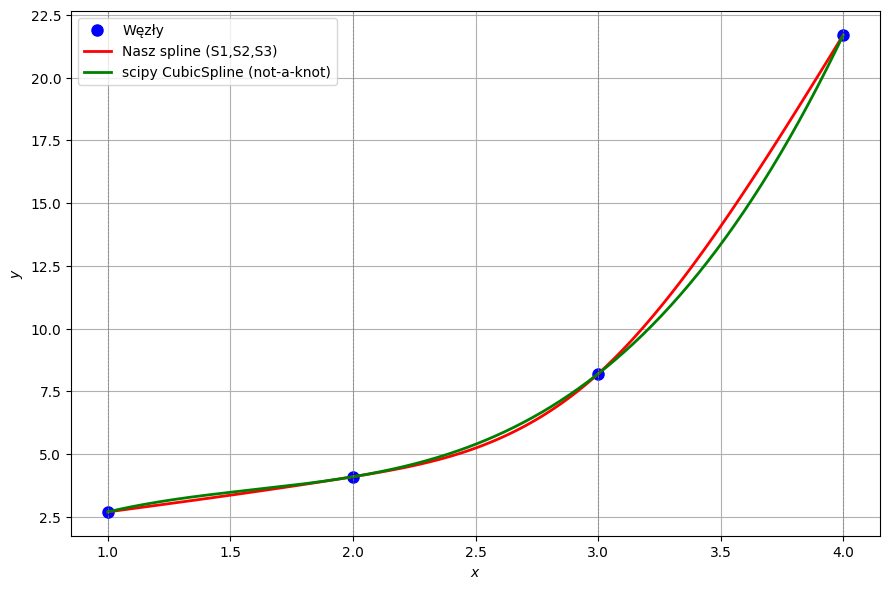

In [9]:
from sympy import lambdify

s1 = lambdify(xxx, S1, modules="numpy")
s2 = lambdify(xxx, S2, modules="numpy")
s3 = lambdify(xxx, S3, modules="numpy")

from scipy.interpolate import CubicSpline
cs = CubicSpline(x, y)

fig, ax = plt.subplots(figsize=(9, 6))
xx_fine = np.linspace(x[0], x[-1], 401)
ax.plot(x, y, "ob", markersize=8, label="Węzły")

xx1 = np.linspace(x[0], x[1], 100)
ax.plot(xx1, s1(xx1), "r", linewidth=2, label="Nasz spline (S1,S2,S3)")
xx2 = np.linspace(x[1], x[2], 100)
ax.plot(xx2, s2(xx2), "r", linewidth=2)
xx3 = np.linspace(x[2], x[3], 100)
ax.plot(xx3, s3(xx3), "r", linewidth=2)

ax.plot(xx_fine, cs(xx_fine), "g", linewidth=2, label="scipy CubicSpline (not-a-knot)")
for xi in x:
    ax.axvline(xi, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend(loc="best")
ax.grid(True)
plt.tight_layout()
plt.show()

## Weryfikacja warunków spline'a naturalnego

Sprawdzamy:
1. Drugie pochodne w węzłach wewnętrznych są ciągłe
2. Drugie pochodne w węzłach skrajnych wynoszą 0

In [10]:
# Druga pochodna S1 i S2 w węźle x[1]
d2S1_x1 = diff(S1, xxx, 2).subs(xxx, x[1]).evalf()
d2S2_x1 = diff(S2, xxx, 2).subs(xxx, x[1]).evalf()
print(f"S1(x1) = {d2S1_x1}")
print(f"S2(x1) = {d2S2_x1}")
print(f"Czy równe: {abs(float(d2S1_x1 - d2S2_x1)) < 1e-8}")

S1(x1) = 0.560000000000000
S2(x1) = 0.559999999999999
Czy równe: True


In [11]:
# Druga pochodna w węźle x[2]
d2S2_x2 = diff(S2, xxx, 2).subs(xxx, x[2]).evalf()
d2S3_x2 = diff(S3, xxx, 2).subs(xxx, x[2]).evalf()
print(f"S2(x2) = {d2S2_x2}")
print(f"S3(x2) = {d2S3_x2}")
print(f"Czy równe: {abs(float(d2S2_x2 - d2S3_x2)) < 1e-8}")

S2(x2) = 13.9600000000000
S3(x2) = 13.9600000000000
Czy równe: True


In [12]:
# Warunek naturalny na brzegach
d2S1_0 = diff(S1, xxx, 2).subs(xxx, x[0]).evalf()
d2S3_n = diff(S3, xxx, 2).subs(xxx, x[-1]).evalf()
print(f"S1(x0) = {d2S1_0}  (powinno być 0)")
print(f"S3(x3) = {d2S3_n}  (powinno być 0)")

S1(x0) = 0  (powinno być 0)
S3(x3) = 0  (powinno być 0)


## Podsumowanie

Choć nasze wyniki różnią się od `scipy.interpolate.CubicSpline`, wszystkie wymagania dla spline'a naturalnego są spełnione. Różnica wynika z faktu, że domyślny spline w SciPy to spline z warunkiem brzegowym 'not-a-knot'.

**Ćwiczenie:** Dla spline kubicznego warunek brzegowy 'not-a-knot' oznacza, że trzecie pochodne w punktach $a$ i $b$ są równe ($S_1^{(3)}=S_2^{(3)}$ i $S_{n-2}^{(3)}=S_{n-1}^{(3)}$). Zmodyfikuj powyższy układ równań i porównaj wyniki.

## Wykorzystywane funkcje
- `np.linalg.solve` — rozwiązywanie układu równań
- `scipy.interpolate.CubicSpline` — gotowy spline kubiczny
- `sympy` — weryfikacja analityczna